# 06D — LungDev raw-count high-confidence backbone: QC → recurrent HVGs → shared normalization → PCA/Harmony/CAGRA

This notebook tests whether the fragmented raw-count UMAP can be stabilized by
letting only sufficiently informative cells and recurrent genes define the
integrated manifold.

## Primary backbone filter

```python
pct_counts_mt < 20
n_genes_by_counts >= 20
total_counts >= 30
```

These are intentionally permissive thresholds for a dataset with a median of
only about 80 detected genes per cell.

## Modeling-feature policy

The notebook keeps genes in the source object but restricts the global
identity manifold to genes that:

```text
are detected in at least 50 retained backbone cells
are an HVG in at least 2 of the 4 samples
are among the top 3,000 recurrent HVGs
are not mitochondrial, ribosomal, hemoglobin, or standard S/G2M genes
```

## Correct normalization order

The previous experimental raw-count branch selected HVGs before
`normalize_total()`. In very sparse cells, that can greatly amplify the few
counts that happen to fall in the HVG subset.

This notebook instead calculates the size factor from **all-gene raw Proseg
counts**:

```text
size factor = 10,000 / all-gene total counts
```

and then applies that factor to the selected-HVG matrix. This is equivalent to:

```text
normalize all genes → log1p → select HVGs
```

without staging all genes as a dense GPU matrix.

## Dimensional reduction and graph

```text
80 PCs are computed
Harmony is run on all 80 PCs
the first 40 Harmony PCs define the graph
50-neighbor CAGRA
UMAP
Leiden at 0.3, 0.5, and 0.8
```

## Cell preservation

Low-information cells are not deleted from the project. Their QC flags are
saved in a full-cell metadata Parquet file. Only the `backbone_keep=True`
subset defines PCA, Harmony, neighbors, UMAP, and Leiden. Those cells can be
projected back onto the reviewed atlas later.


In [1]:
# FIRST CELL — run before importing CuPy, RAPIDS, PyTorch, or TensorFlow
import os

GPU_IDS = os.environ.get(
    "LUNGDEV_RAPIDS_GPU_IDS",
    "0,1,2,3",
)
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_IDS

print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])


CUDA_VISIBLE_DEVICES: 0,1,2,3


In [2]:
# ---------------------------------------------------------------------
# Imports and configuration
# ---------------------------------------------------------------------
from __future__ import annotations

import copy
import gc
import hashlib
import importlib.metadata as metadata
import json
import math
import os
import re
import shutil
import sys
import traceback
import warnings
from collections.abc import Mapping
from pathlib import Path

import anndata as ad
import cupy as cp
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rapids_singlecell as rsc
import scanpy as sc
import scipy.sparse as sp
import zarr

from dask.distributed import Client, wait
from dask_cuda import LocalCUDACluster
from packaging.version import Version
from IPython.display import display
from scipy.sparse.csgraph import connected_components

warnings.filterwarnings("ignore")
sc.settings.verbosity = 2
sc.settings.set_figure_params(
    dpi=100,
    frameon=False,
    fontsize=9,
)

PROJECT_ROOT = Path(
    "/host_root/nethome/reny28/Projects/ShortProject/"
    "LungDev_VisiumHD_example"
)
PIPELINE_ROOT = (
    PROJECT_ROOT
    / "tmp"
    / "lungdev_stardist_proseg_resolvi_v1"
)
RAPIDS_ROOT = PIPELINE_ROOT / "06_rapids_multigpu"
PCA06A_ROOT = RAPIDS_ROOT / "06A_pca"

OUTPUT_ROOT = (
    RAPIDS_ROOT
    / "06D_rawcounts_backboneQC_recurrentHVG"
)
QC_ROOT = OUTPUT_ROOT / "01_backbone_qc"
STAGE_ROOT = OUTPUT_ROOT / "02_lognorm_hvg_stage"
PCA_ROOT = OUTPUT_ROOT / "03_pca"
GRAPH_ROOT = OUTPUT_ROOT / "04_harmony_graph"
FIGURE_ROOT = OUTPUT_ROOT / "figures"
TABLE_ROOT = OUTPUT_ROOT / "tables"
DASK_LOCAL_DIRECTORY = OUTPUT_ROOT / "dask_tmp"

for directory in [
    OUTPUT_ROOT,
    QC_ROOT,
    STAGE_ROOT,
    PCA_ROOT,
    GRAPH_ROOT,
    FIGURE_ROOT,
    TABLE_ROOT,
    DASK_LOCAL_DIRECTORY,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

SAMPLE_IDS = [
    "D142_RLL_5B1_8",
    "D430_RLL_7A2_6",
    "D327_RLL_4A2_6",
    "D194_RLL_5A2_6",
]

# ------------------------------------------------------------------
# Raw source
# ------------------------------------------------------------------
RAW_CHECKPOINT_CANDIDATES = [
    (
        PCA06A_ROOT
        / "LungDev_analysis_core_raw_counts_HVG.h5ad"
    ),
    (
        PIPELINE_ROOT
        / "06_harmony_leiden_annotation"
        / "LungDev_analysis_core_raw_counts.h5ad"
    ),
]

# ------------------------------------------------------------------
# Backbone cell filter
# ------------------------------------------------------------------
MAX_PCT_COUNTS_MT = 20.0
MIN_GENES_BY_COUNTS = 20
MIN_TOTAL_COUNTS = 30

# No additional MAD-based cell exclusion is applied in this controlled test.
# Existing QC/outlier columns remain available in obs for diagnostics.

# ------------------------------------------------------------------
# Modeling-gene/HVG selection
# ------------------------------------------------------------------
MIN_CELLS_PER_MODEL_GENE = 50
MIN_HVG_BATCHES = 2
HVG_CANDIDATE_POOL = 6000
N_IDENTITY_HVG = 3000
MIN_ACCEPTABLE_IDENTITY_HVG = 1500
EXCLUDE_CELL_CYCLE_FROM_IDENTITY_HVG = True

# ------------------------------------------------------------------
# Shared normalization / PCA
# ------------------------------------------------------------------
TARGET_SUM = 10_000.0
ROW_CHUNK_SIZE = 20_000
N_PCS = 80
SCALE_ZERO_CENTER = True
SCALE_MAX_VALUE = 10.0
RANDOM_SEED = 17

# ------------------------------------------------------------------
# Dask-CUDA
# ------------------------------------------------------------------
DASK_DEVICE_MEMORY_LIMIT = "18GB"
DASK_RMM_POOL_SIZE = "10GB"
DASK_RMM_MAXIMUM_POOL_SIZE = "18GB"
DASK_HOST_MEMORY_LIMIT_PER_WORKER = "80GB"
DASK_PROTOCOL = "tcp"
DASK_THREADS_PER_WORKER = 1

# ------------------------------------------------------------------
# Harmony / graph
# ------------------------------------------------------------------
HARMONY_GPU = 0
HARMONY_FLAVOR_REQUESTED = "harmony1"

HARMONY_THETA = 4.0
HARMONY_TAU = 0
HARMONY_RIDGE_LAMBDA = 0.5
HARMONY_SIGMA = 0.1
HARMONY_N_CLUSTERS = 100
HARMONY_MAX_ITER = 20
HARMONY_MAX_ITER_CLUSTERING = 200
HARMONY_TOL = 1e-4
HARMONY_TOL_CLUSTERING = 1e-5
HARMONY_BLOCK_PROPORTION = 0.05
HARMONY_MIN_RELATIVE_L2_CHANGE = 1e-5

N_HARMONY_PCS_FOR_GRAPH = 40
N_NEIGHBORS = 50
NEIGHBOR_ALGORITHM = "cagra"

HARMONY_AUDIT_MAX_CELLS = 100_000
HARMONY_AUDIT_NEIGHBORS = 50

UMAP_MIN_DIST = 0.3
UMAP_INIT_POS = "random"

LEIDEN_RESOLUTIONS = (
    0.3,
    0.5,
    0.8,
)
PRIMARY_LEIDEN_KEY = "leiden_0p5"

# ------------------------------------------------------------------
# Output reuse
# ------------------------------------------------------------------
OVERWRITE_BACKBONE_STAGE = False
OVERWRITE_PCA = False
OVERWRITE_GRAPH = False
PLOT_MAX_CELLS = 250_000

ALL_CELL_QC_PARQUET = (
    QC_ROOT / "LungDev_all_cells_backbone_QC_flags.parquet"
)
BACKBONE_QC_SUMMARY_CSV = (
    TABLE_ROOT / "LungDev_backbone_QC_summary_by_sample.csv"
)
GENE_MODELING_TABLE_CSV = (
    TABLE_ROOT / "LungDev_backbone_gene_modeling_flags.csv"
)
SELECTED_HVG_CSV = (
    TABLE_ROOT / "LungDev_backbone_recurrent_identity_HVGs.csv"
)

LOGNORM_STAGE_ZARR = (
    STAGE_ROOT
    / "LungDev_backbone_allgeneSF_log1p_recurrentHVG.zarr"
)
LOGNORM_STAGE_MANIFEST = (
    STAGE_ROOT
    / "LungDev_backbone_allgeneSF_log1p_recurrentHVG_manifest.json"
)

PCA_CHECKPOINT_H5AD = (
    PCA_ROOT
    / "LungDev_backbone_rawcounts_PCA80_checkpoint.h5ad"
)
PCA_EMBEDDING_NPY = (
    PCA_ROOT
    / "LungDev_backbone_rawcounts_X_pca80_float32.npy"
)
PCA_LOADINGS_NPY = (
    PCA_ROOT
    / "LungDev_backbone_rawcounts_PCA_loadings_float32.npy"
)
PCA_STATS_NPZ = (
    PCA_ROOT
    / "LungDev_backbone_rawcounts_PCA_variance_stats.npz"
)
PCA_MANIFEST_JSON = (
    PCA_ROOT
    / "LungDev_backbone_rawcounts_PCA80_manifest.json"
)

HARMONY_EMBEDDING_NPY = (
    GRAPH_ROOT
    / "LungDev_backbone_X_pca_harmony80_float32.npy"
)
HARMONY_AUDIT_JSON = (
    GRAPH_ROOT
    / "LungDev_backbone_Harmony_embedding_audit.json"
)
HARMONY_SUBSET_MIXING_CSV = (
    TABLE_ROOT
    / "LungDev_backbone_Harmony_subset_neighbor_mixing.csv"
)

GRAPH_CHECKPOINT_H5AD = (
    GRAPH_ROOT
    / "LungDev_backbone_Harmony40_CAGRA50_UMAP_Leiden.h5ad"
)
GRAPH_MANIFEST_JSON = (
    GRAPH_ROOT
    / "LungDev_backbone_graph_manifest.json"
)
INTEGRATION_AUDIT_CSV = (
    TABLE_ROOT
    / "LungDev_backbone_integration_audit_summary.csv"
)
GRAPH_COMPONENTS_CSV = (
    TABLE_ROOT
    / "LungDev_backbone_graph_connected_components.csv"
)
CLUSTER_QC_CSV = (
    TABLE_ROOT
    / f"LungDev_backbone_{PRIMARY_LEIDEN_KEY}_cluster_QC.csv"
)
CLUSTER_SAMPLE_PURITY_CSV = (
    TABLE_ROOT
    / f"LungDev_backbone_{PRIMARY_LEIDEN_KEY}_sample_purity.csv"
)
ANNOTATION_TEMPLATE_CSV = (
    TABLE_ROOT
    / f"LungDev_backbone_{PRIMARY_LEIDEN_KEY}_annotation_template.csv"
)

PRIOR_BRANCH_AUDIT_CANDIDATES = {
    "per_sample_ResolVI_corrected": [
        (
            RAPIDS_ROOT
            / "06B_graph_harmony_audit_v3_h5adsafe"
            / "tables"
            / "integration_audit_summary.csv"
        ),
        (
            RAPIDS_ROOT
            / "06B_graph_harmony_audit_v2"
            / "tables"
            / "integration_audit_summary.csv"
        ),
    ],
    "raw_all_analysis_core_old06C": [
        (
            RAPIDS_ROOT
            / "06C_rawcounts_harmony_cagra_80pc"
            / "tables"
            / "rawcounts_integration_audit_summary.csv"
        ),
    ],
}

BRANCH_COMPARISON_CSV = (
    TABLE_ROOT
    / "LungDev_integration_branch_comparison.csv"
)

print("Python:", sys.executable)
print("Visible GPUs:", cp.cuda.runtime.getDeviceCount())
print("Output root:", OUTPUT_ROOT)


/home/domino/reny28/Projects/Visium_projects/TBIO-8057/env/gpu_env/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /home/domino/reny28/Projects/Visium_projects/TBIO-8057/env/gpu_env/.venv/bin/python
Visible GPUs: 4
Output root: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06D_rawcounts_backboneQC_recurrentHVG


In [3]:
# ---------------------------------------------------------------------
# Version and input preflight
# ---------------------------------------------------------------------
def detect_rapids_singlecell_version():
    candidates = []

    candidates.extend(
        metadata.packages_distributions().get(
            "rapids_singlecell",
            [],
        )
    )
    candidates.extend(
        [
            "rapids-singlecell-cu13",
            "rapids-singlecell-cu12",
            "rapids-singlecell",
            "rapids_singlecell",
        ]
    )
    candidates = list(
        dict.fromkeys(candidates)
    )

    for distribution_name in candidates:
        try:
            return (
                Version(
                    str(
                        metadata.version(
                            distribution_name
                        )
                    )
                ),
                distribution_name,
            )
        except metadata.PackageNotFoundError:
            continue

    module_version = getattr(
        rsc,
        "__version__",
        None,
    )
    if module_version not in {None, ""}:
        return (
            Version(str(module_version)),
            "rapids_singlecell.__version__",
        )

    try:
        from rapids_singlecell._version import __version__

        return (
            Version(str(__version__)),
            "rapids_singlecell._version.__version__",
        )
    except Exception:
        pass

    raise RuntimeError(
        "rapids_singlecell imported but its version could not "
        "be determined."
    )


rsc_version, rsc_distribution_name = (
    detect_rapids_singlecell_version()
)

print(
    "rapids-singlecell:",
    rsc_version,
    f"(detected from {rsc_distribution_name})",
)
print(
    "rapids_singlecell module:",
    getattr(rsc, "__file__", "unknown"),
)

if rsc_version < Version("0.11.0"):
    raise RuntimeError(
        "rapids-singlecell >= 0.11.0 is required."
    )

requested_gpu_count = len(
    [
        value
        for value in GPU_IDS.split(",")
        if value.strip()
    ]
)

if (
    cp.cuda.runtime.getDeviceCount()
    != requested_gpu_count
):
    raise RuntimeError(
        f"Expected {requested_gpu_count} visible GPUs, but CuPy "
        f"sees {cp.cuda.runtime.getDeviceCount()}. Restart the kernel "
        "and run the GPU-visibility cell first."
    )

raw_checkpoint_path = next(
    (
        path
        for path in RAW_CHECKPOINT_CANDIDATES
        if path.exists()
    ),
    None,
)

if raw_checkpoint_path is None:
    raise FileNotFoundError(
        "No combined all-gene raw-count checkpoint was found. "
        "Candidates:\n"
        + "\n".join(
            str(path)
            for path in RAW_CHECKPOINT_CANDIDATES
        )
    )

print("Raw all-gene checkpoint:", raw_checkpoint_path)


rapids-singlecell: 0.15.0rc5 (detected from rapids-singlecell-cu13)
rapids_singlecell module: /home/domino/reny28/Projects/Visium_projects/TBIO-8057/env/gpu_env/.venv/lib/python3.13/site-packages/rapids_singlecell/__init__.py
Raw all-gene checkpoint: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_harmony_leiden_annotation/LungDev_analysis_core_raw_counts.h5ad


## 1. Build or reuse the high-confidence backbone stage

The first run performs the following CPU/sparse operations:

1. read the all-gene raw-count checkpoint;
2. flag all cells by the three requested thresholds;
3. subset the backbone cells;
4. calculate gene detection frequency in those cells;
5. run batch-aware Seurat-v3 HVG selection from raw counts;
6. select the top 3,000 recurrent/eligible identity HVGs;
7. calculate all-gene size factors;
8. normalize only the selected-HVG matrix with those all-gene size factors;
9. apply `log1p`;
10. write a sparse float32 Zarr for multi-GPU scaling/PCA.

The raw source checkpoint and excluded cells remain unchanged.


In [4]:
# ---------------------------------------------------------------------
# H5AD/Zarr-safe and selection helper functions
# ---------------------------------------------------------------------
S_GENES = [
    "MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1",
    "UNG", "GINS2", "MCM6", "CDCA7", "DTL", "PRIM1", "UHRF1",
    "MLF1IP", "HELLS", "RFC2", "RPA2", "NASP", "RAD51AP1",
    "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7", "POLD3",
    "MSH2", "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6",
    "EXO1", "TIPIN", "DSCC1", "BLM", "CASP8AP2", "USP1",
    "CLSPN", "POLA1", "CHAF1B", "BRIP1", "E2F8",
]

G2M_GENES = [
    "HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2",
    "TOP2A", "NDC80", "CKS2", "NUF2", "CKS1B", "MKI67",
    "TMPO", "CENPF", "TACC3", "FAM64A", "SMC4", "CCNB2",
    "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E",
    "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1",
    "CDC20", "TTK", "CDC25C", "KIF2C", "RANGAP1", "NCAPD2",
    "DLGAP5", "CDCA2", "CDCA8", "ECT2", "KIF23", "HMMR",
    "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5", "CENPE",
    "CTCF", "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA",
]


def hash_index(values) -> str:
    digest = hashlib.sha256()

    for value in values:
        digest.update(
            str(value).encode("utf-8")
        )
        digest.update(b"\n")

    return digest.hexdigest()


def source_signature(path: Path) -> dict:
    stat = path.stat()

    return {
        "path": str(path),
        "size_bytes": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def get_sparse_counts(
    adata_obj: ad.AnnData,
):
    matrix = (
        adata_obj.layers["counts"]
        if "counts" in adata_obj.layers
        else adata_obj.X
    )

    if not sp.issparse(matrix):
        matrix = sp.csr_matrix(matrix)
    else:
        matrix = matrix.tocsr(copy=False)

    matrix.sum_duplicates()
    matrix.eliminate_zeros()
    matrix.sort_indices()

    return matrix


def validate_integer_counts(
    matrix,
    tolerance=1e-6,
):
    matrix = get_sparse_counts(
        ad.AnnData(X=matrix)
    )

    if matrix.data.size:
        maximum_error = float(
            np.max(
                np.abs(
                    matrix.data
                    - np.rint(matrix.data)
                )
            )
        )
    else:
        maximum_error = 0.0

    print(
        "Maximum count fractional deviation:",
        maximum_error,
    )

    if maximum_error > tolerance:
        raise ValueError(
            "The selected matrix is not integer-like raw count data."
        )

    return matrix


def stage_configuration() -> dict:
    return {
        "source": source_signature(
            raw_checkpoint_path
        ),
        "max_pct_counts_mt": float(
            MAX_PCT_COUNTS_MT
        ),
        "min_genes_by_counts": int(
            MIN_GENES_BY_COUNTS
        ),
        "min_total_counts": int(
            MIN_TOTAL_COUNTS
        ),
        "min_cells_per_model_gene": int(
            MIN_CELLS_PER_MODEL_GENE
        ),
        "min_hvg_batches": int(
            MIN_HVG_BATCHES
        ),
        "hvg_candidate_pool": int(
            HVG_CANDIDATE_POOL
        ),
        "n_identity_hvg": int(
            N_IDENTITY_HVG
        ),
        "exclude_cell_cycle": bool(
            EXCLUDE_CELL_CYCLE_FROM_IDENTITY_HVG
        ),
        "target_sum": float(
            TARGET_SUM
        ),
    }


def stage_is_usable() -> bool:
    if not (
        LOGNORM_STAGE_ZARR.exists()
        and LOGNORM_STAGE_MANIFEST.exists()
        and ALL_CELL_QC_PARQUET.exists()
        and BACKBONE_QC_SUMMARY_CSV.exists()
        and GENE_MODELING_TABLE_CSV.exists()
        and SELECTED_HVG_CSV.exists()
    ):
        return False

    try:
        manifest_data = json.loads(
            LOGNORM_STAGE_MANIFEST.read_text()
        )

        if (
            manifest_data.get("configuration")
            != stage_configuration()
        ):
            print(
                "Existing stage configuration differs; rebuilding."
            )
            return False

        root = zarr.open_group(
            str(LOGNORM_STAGE_ZARR),
            mode="r",
        )

        if "X" not in root:
            return False

        shape = tuple(
            root["X"].attrs.get(
                "shape",
                (),
            )
        )

        return (
            shape
            == tuple(
                manifest_data.get(
                    "shape",
                    [],
                )
            )
            and shape[0] > 0
            and shape[1] >= (
                MIN_ACCEPTABLE_IDENTITY_HVG
            )
        )

    except Exception as exc:
        print(
            "Existing stage is not reusable:",
            type(exc).__name__,
            exc,
        )
        return False


def write_zarr_atomically(
    adata_obj: ad.AnnData,
    path: Path,
):
    temporary = path.with_name(
        path.name + ".tmp"
    )

    if temporary.exists():
        shutil.rmtree(temporary)

    adata_obj.write_zarr(
        temporary
    )

    root = zarr.open_group(
        str(temporary),
        mode="r",
    )
    shape = tuple(
        root["X"].attrs.get(
            "shape",
            (),
        )
    )

    if shape != adata_obj.shape:
        raise ValueError(
            f"Zarr read-back shape {shape} does not match "
            f"{adata_obj.shape}."
        )

    if path.exists():
        shutil.rmtree(path)

    temporary.replace(path)


In [5]:
# ---------------------------------------------------------------------
# Build/reuse backbone cell set, recurrent HVGs, and corrected lognorm stage
# ---------------------------------------------------------------------
if (
    stage_is_usable()
    and not OVERWRITE_BACKBONE_STAGE
):
    print(
        "Reusing validated backbone stage:",
        LOGNORM_STAGE_ZARR,
    )

    root = zarr.open_group(
        str(LOGNORM_STAGE_ZARR),
        mode="r",
    )
    stage_obs = ad.io.read_elem(
        root["obs"]
    )
    stage_var = ad.io.read_elem(
        root["var"]
    )

    stage_obs.index = pd.Index(
        stage_obs.index.astype(str),
        name=None,
    )
    stage_var.index = pd.Index(
        stage_var.index.astype(str),
        name=None,
    )

    selected_hvg = pd.Index(
        stage_var.index.astype(str),
        name=None,
    )

else:
    print(
        "Opening all-gene raw checkpoint:",
        raw_checkpoint_path,
    )

    backed = ad.read_h5ad(
        raw_checkpoint_path,
        backed="r",
    )

    try:
        required_obs = {
            "sample",
            "total_counts",
            "n_genes_by_counts",
            "pct_counts_mt",
        }
        missing_obs = required_obs.difference(
            set(backed.obs.columns)
        )

        if missing_obs:
            raise KeyError(
                "Raw checkpoint is missing required QC columns: "
                f"{sorted(missing_obs)}"
            )

        all_obs = backed.obs.copy()
        all_obs.index = pd.Index(
            backed.obs_names.astype(str),
            name=None,
        )

        all_obs[
            "backbone_fail_mito"
        ] = (
            all_obs["pct_counts_mt"]
            >= MAX_PCT_COUNTS_MT
        )
        all_obs[
            "backbone_fail_genes"
        ] = (
            all_obs[
                "n_genes_by_counts"
            ]
            < MIN_GENES_BY_COUNTS
        )
        all_obs[
            "backbone_fail_counts"
        ] = (
            all_obs["total_counts"]
            < MIN_TOTAL_COUNTS
        )

        all_obs["backbone_keep"] = ~(
            all_obs[
                [
                    "backbone_fail_mito",
                    "backbone_fail_genes",
                    "backbone_fail_counts",
                ]
            ].any(axis=1)
        )

        fail_reason = np.full(
            len(all_obs),
            "",
            dtype=object,
        )

        reason_mapping = [
            (
                "backbone_fail_mito",
                "pct_counts_mt>=20",
            ),
            (
                "backbone_fail_genes",
                "n_genes_by_counts<20",
            ),
            (
                "backbone_fail_counts",
                "total_counts<30",
            ),
        ]

        for column, reason in reason_mapping:
            mask = all_obs[
                column
            ].to_numpy(dtype=bool)

            fail_reason[mask] = np.where(
                fail_reason[mask] == "",
                reason,
                fail_reason[mask]
                + ";"
                + reason,
            )

        all_obs[
            "backbone_fail_reason"
        ] = fail_reason

        all_obs.to_parquet(
            ALL_CELL_QC_PARQUET
        )

        qc_summary = (
            all_obs.groupby(
                "sample",
                observed=True,
            )
            .agg(
                n_input_cells=(
                    "backbone_keep",
                    "size",
                ),
                n_backbone_cells=(
                    "backbone_keep",
                    "sum",
                ),
                fraction_backbone=(
                    "backbone_keep",
                    "mean",
                ),
                n_fail_mito=(
                    "backbone_fail_mito",
                    "sum",
                ),
                n_fail_genes=(
                    "backbone_fail_genes",
                    "sum",
                ),
                n_fail_counts=(
                    "backbone_fail_counts",
                    "sum",
                ),
                median_total_counts=(
                    "total_counts",
                    "median",
                ),
                median_n_genes=(
                    "n_genes_by_counts",
                    "median",
                ),
                median_pct_mt=(
                    "pct_counts_mt",
                    "median",
                ),
            )
            .reset_index()
        )

        qc_summary.to_csv(
            BACKBONE_QC_SUMMARY_CSV,
            index=False,
        )
        display(qc_summary)

        keep = all_obs[
            "backbone_keep"
        ].to_numpy(dtype=bool)

        if keep.sum() < 10_000:
            raise RuntimeError(
                "Backbone filter retained fewer than 10,000 cells; "
                "check the QC columns and thresholds."
            )

        print(
            "Materializing filtered all-gene sparse object:",
            f"{int(keep.sum()):,} cells",
        )

        backbone = backed[
            keep,
            :,
        ].to_memory()

    finally:
        try:
            backed.file.close()
        except Exception:
            pass

    backbone.obs = (
        all_obs.loc[
            backbone.obs_names
        ].copy()
    )
    backbone.obs.index = pd.Index(
        backbone.obs.index.astype(str),
        name=None,
    )
    backbone.var.index = pd.Index(
        backbone.var.index.astype(str),
        name=None,
    )

    counts = get_sparse_counts(
        backbone
    )
    validate_integer_counts(
        counts
    )

    # Recalculate totals from the all-gene matrix and validate the existing
    # QC column before using those totals as size factors.
    all_gene_totals = np.asarray(
        counts.sum(axis=1)
    ).reshape(-1).astype(
        np.float64,
        copy=False,
    )

    existing_totals = backbone.obs[
        "total_counts"
    ].to_numpy(dtype=np.float64)

    total_difference = np.abs(
        all_gene_totals
        - existing_totals
    )

    print(
        "Maximum |all-gene matrix total - obs total_counts|:",
        float(
            np.max(total_difference)
        ),
    )

    if np.max(total_difference) > 1e-4:
        warnings.warn(
            "obs['total_counts'] differs from the all-gene raw count "
            "matrix. The matrix-derived totals will be used."
        )

    if np.any(all_gene_totals <= 0):
        raise ValueError(
            "Backbone contains cells with zero all-gene counts."
        )

    backbone.obs[
        "all_gene_total_counts_for_normalization"
    ] = all_gene_totals.astype(
        np.float32
    )
    backbone.obs[
        "all_gene_size_factor_to_10k"
    ] = (
        TARGET_SUM
        / all_gene_totals
    ).astype(np.float32)

    # Gene detection frequency among retained backbone cells.
    n_cells_by_counts = np.asarray(
        (counts > 0).sum(axis=0)
    ).reshape(-1).astype(
        np.int64,
        copy=False,
    )
    backbone.var[
        "n_cells_by_counts_backbone"
    ] = n_cells_by_counts

    names_upper = pd.Index(
        backbone.var_names.astype(str).str.upper()
    )

    backbone.var["mt"] = np.asarray(
        names_upper.str.startswith(
            ("MT-", "MT_")
        ),
        dtype=bool,
    )
    backbone.var["ribo"] = np.asarray(
        names_upper.str.startswith(
            ("RPS", "RPL")
        ),
        dtype=bool,
    )
    backbone.var["hb"] = np.asarray(
        names_upper.str.match(
            r"^HB(?!P)"
        ),
        dtype=bool,
    )
    backbone.var[
        "cell_cycle_gene"
    ] = np.asarray(
        names_upper.isin(
            set(S_GENES)
            | set(G2M_GENES)
        ),
        dtype=bool,
    )

    backbone.var[
        "gene_detected_in_min_cells"
    ] = (
        backbone.var[
            "n_cells_by_counts_backbone"
        ]
        >= MIN_CELLS_PER_MODEL_GENE
    )

    # Batch-aware HVG selection from unmodified raw integer counts.
    if "counts" not in backbone.layers:
        backbone.layers[
            "counts"
        ] = counts

    sc.pp.highly_variable_genes(
        backbone,
        layer="counts",
        flavor="seurat_v3",
        n_top_genes=HVG_CANDIDATE_POOL,
        batch_key="sample",
        subset=False,
        check_values=True,
    )

    technical_exclusion = (
        backbone.var["mt"]
        | backbone.var["ribo"]
        | backbone.var["hb"]
    )

    if (
        EXCLUDE_CELL_CYCLE_FROM_IDENTITY_HVG
    ):
        technical_exclusion = (
            technical_exclusion
            | backbone.var[
                "cell_cycle_gene"
            ]
        )

    backbone.var[
        "recurrent_hvg_eligible"
    ] = (
        backbone.var[
            "highly_variable"
        ].astype(bool)
        & (
            backbone.var[
                "highly_variable_nbatches"
            ]
            >= MIN_HVG_BATCHES
        )
        & backbone.var[
            "gene_detected_in_min_cells"
        ].astype(bool)
        & ~technical_exclusion
    )

    eligible = (
        backbone.var.loc[
            backbone.var[
                "recurrent_hvg_eligible"
            ]
        ]
        .copy()
    )

    eligible[
        "_gene_name"
    ] = eligible.index.astype(str)

    eligible = eligible.sort_values(
        by=[
            "highly_variable_nbatches",
            "highly_variable_rank",
            "variances_norm",
            "_gene_name",
        ],
        ascending=[
            False,
            True,
            False,
            True,
        ],
        na_position="last",
    )

    selected_hvg = pd.Index(
        eligible.head(
            N_IDENTITY_HVG
        ).index.astype(str),
        name=None,
    )

    if (
        len(selected_hvg)
        < MIN_ACCEPTABLE_IDENTITY_HVG
    ):
        raise RuntimeError(
            f"Only {len(selected_hvg)} recurrent eligible HVGs were "
            "available; inspect the gene-filter settings."
        )

    backbone.var[
        "selected_identity_hvg"
    ] = backbone.var_names.isin(
        selected_hvg
    )

    backbone.var.to_csv(
        GENE_MODELING_TABLE_CSV
    )
    pd.DataFrame(
        {
            "gene": selected_hvg,
        }
    ).to_csv(
        SELECTED_HVG_CSV,
        index=False,
    )

    hvg_summary = pd.DataFrame(
        {
            "metric": [
                "all_genes",
                "detected_in_at_least_50_cells",
                "batch_HVG_candidates",
                "HVG_in_at_least_2_samples",
                "recurrent_eligible_after_exclusions",
                "selected_identity_HVGs",
            ],
            "n_genes": [
                int(backbone.n_vars),
                int(
                    backbone.var[
                        "gene_detected_in_min_cells"
                    ].sum()
                ),
                int(
                    backbone.var[
                        "highly_variable"
                    ].sum()
                ),
                int(
                    (
                        backbone.var[
                            "highly_variable_nbatches"
                        ]
                        >= MIN_HVG_BATCHES
                    ).sum()
                ),
                int(
                    backbone.var[
                        "recurrent_hvg_eligible"
                    ].sum()
                ),
                int(
                    backbone.var[
                        "selected_identity_hvg"
                    ].sum()
                ),
            ],
        }
    )
    display(hvg_summary)
    hvg_summary.to_csv(
        TABLE_ROOT
        / "LungDev_backbone_HVG_selection_summary.csv",
        index=False,
    )

    hvg_counts = counts[
        :,
        backbone.var_names.get_indexer(
            selected_hvg
        ),
    ].astype(
        np.float32
    )

    size_factors = (
        TARGET_SUM
        / all_gene_totals
    ).astype(
        np.float32
    )

    lognorm_hvg = hvg_counts.multiply(
        size_factors[:, None]
    ).tocsr()

    lognorm_hvg.data = np.log1p(
        lognorm_hvg.data
    ).astype(
        np.float32,
        copy=False,
    )
    lognorm_hvg.eliminate_zeros()
    lognorm_hvg.sort_indices()

    stage_obs = backbone.obs.copy()
    stage_obs.index = pd.Index(
        stage_obs.index.astype(str),
        name=None,
    )

    stage_var = backbone.var.loc[
        selected_hvg
    ].copy()
    stage_var.index = pd.Index(
        stage_var.index.astype(str),
        name=None,
    )

    stage = ad.AnnData(
        X=lognorm_hvg,
        obs=stage_obs,
        var=stage_var,
        layers={
            "counts": hvg_counts.astype(
                np.uint32
            ),
        },
    )

    if (
        "spatial_x_um"
        in stage.obs.columns
        and "spatial_y_um"
        in stage.obs.columns
    ):
        stage.obsm[
            "spatial"
        ] = stage.obs[
            [
                "spatial_x_um",
                "spatial_y_um",
            ]
        ].to_numpy(
            dtype=np.float32
        )
    elif "spatial" in backbone.obsm:
        stage.obsm[
            "spatial"
        ] = np.asarray(
            backbone.obsm["spatial"],
            dtype=np.float32,
        )

    write_zarr_atomically(
        stage,
        LOGNORM_STAGE_ZARR,
    )

    stage_manifest = {
        "configuration": stage_configuration(),
        "shape": list(
            map(int, stage.shape)
        ),
        "obs_hash": hash_index(
            stage.obs_names
        ),
        "var_hash": hash_index(
            stage.var_names
        ),
        "n_input_cells": int(
            len(all_obs)
        ),
        "n_backbone_cells": int(
            stage.n_obs
        ),
        "fraction_backbone": float(
            stage.n_obs
            / len(all_obs)
        ),
        "normalization": (
            "selected-HVG raw counts multiplied by "
            "10,000 / all-gene raw-count row sum, then natural log1p"
        ),
        "X_dtype": str(
            stage.X.dtype
        ),
        "counts_layer_dtype": str(
            stage.layers[
                "counts"
            ].dtype
        ),
    }

    LOGNORM_STAGE_MANIFEST.write_text(
        json.dumps(
            stage_manifest,
            indent=2,
        )
    )

    del (
        backbone,
        counts,
        hvg_counts,
        lognorm_hvg,
        stage,
    )
    gc.collect()

print(
    "Backbone stage:",
    LOGNORM_STAGE_ZARR,
)
print(
    "Backbone cells:",
    f"{len(stage_obs):,}",
)
print(
    "Selected recurrent HVGs:",
    len(selected_hvg),
)


Opening all-gene raw checkpoint: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_harmony_leiden_annotation/LungDev_analysis_core_raw_counts.h5ad


,sample,n_input_cells,n_backbone_cells,fraction_backbone,n_fail_mito,n_fail_genes,n_fail_counts,median_total_counts,median_n_genes,median_pct_mt
0,D142_RLL_5B1_8,123479,91730,0.742879,0,10682,31717,49.0,47.0,2.362205
1,D194_RLL_5A2_6,210908,167757,0.795404,0,13700,43117,56.0,54.0,1.562500
2,D327_RLL_4A2_6,207621,173726,0.836746,0,10832,33861,70.0,67.0,2.054795
3,D430_RLL_7A2_6,207753,190437,0.916651,0,4749,17316,99.0,95.0,1.176471


Materializing filtered all-gene sparse object: 623,650 cells
Maximum count fractional deviation: 0.0
Maximum |all-gene matrix total - obs total_counts|: 80.0
extracting highly variable genes


,metric,n_genes
0,all_genes,18384
1,detected_in_at_least_50_cells,17762
2,batch_HVG_candidates,6000
3,HVG_in_at_least_2_samples,6870
4,recurrent_eligible_after_exclusions,3502
5,selected_identity_HVGs,3000


... storing 'backbone_fail_reason' as categorical


Backbone stage: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06D_rawcounts_backboneQC_recurrentHVG/02_lognorm_hvg_stage/LungDev_backbone_allgeneSF_log1p_recurrentHVG.zarr
Backbone cells: 623,650
Selected recurrent HVGs: 3000


## 2. Multi-GPU scaling and 80-PC PCA

The stage already contains sparse `float32`:

```text
all-gene-size-factor normalized
natural-log1p transformed
selected-HVG expression
```

Therefore the GPU section performs only:

```text
zero-centered scaling
80-PC PCA
```

The resulting PCA checkpoint has an empty sparse `.X`; expression remains in
the stage Zarr.


In [6]:
# ---------------------------------------------------------------------
# Dask-CUDA, lazy Zarr, and GPU cleanup helpers
# ---------------------------------------------------------------------
def start_cuda_cluster():
    base = {
        "CUDA_VISIBLE_DEVICES": GPU_IDS,
        "threads_per_worker": (
            DASK_THREADS_PER_WORKER
        ),
        "protocol": DASK_PROTOCOL,
        "device_memory_limit": (
            DASK_DEVICE_MEMORY_LIMIT
        ),
        "memory_limit": (
            DASK_HOST_MEMORY_LIMIT_PER_WORKER
        ),
        "local_directory": str(
            DASK_LOCAL_DIRECTORY
        ),
    }

    attempts = [
        {
            **base,
            "rmm_pool_size": (
                DASK_RMM_POOL_SIZE
            ),
            "rmm_maximum_pool_size": (
                DASK_RMM_MAXIMUM_POOL_SIZE
            ),
            "rmm_allocator_external_lib_list": (
                "cupy"
            ),
        },
        {
            **base,
            "rmm_pool_size": (
                DASK_RMM_POOL_SIZE
            ),
            "rmm_allocator_external_lib_list": (
                "cupy"
            ),
        },
        {
            **base,
            "rmm_pool_size": (
                DASK_RMM_POOL_SIZE
            ),
        },
        base,
    ]

    failures = []

    for kwargs in attempts:
        try:
            cluster_obj = LocalCUDACluster(
                **kwargs
            )
            client_obj = Client(
                cluster_obj
            )
            client_obj.wait_for_workers(
                requested_gpu_count
            )
            return (
                cluster_obj,
                client_obj,
                kwargs,
            )

        except Exception as exc:
            failures.append(
                {
                    "kwargs": kwargs,
                    "error": (
                        f"{type(exc).__name__}: {exc}"
                    ),
                }
            )
            print(
                "Cluster attempt failed; trying simpler settings:",
                failures[-1]["error"],
            )

    raise RuntimeError(
        "All LocalCUDACluster attempts failed:\n"
        + json.dumps(
            failures,
            indent=2,
            default=str,
        )
    )


def read_stage_lazy(
    path: Path,
):
    root = zarr.open_group(
        str(path),
        mode="r",
    )

    x_element = root["X"]
    shape = tuple(
        x_element.attrs[
            "shape"
        ]
    )

    try:
        from anndata.experimental import (
            read_elem_lazy as read_dask,
        )
    except ImportError:
        from anndata.experimental import (
            read_elem_as_dask as read_dask,
        )

    X_lazy = read_dask(
        x_element,
        (
            ROW_CHUNK_SIZE,
            shape[1],
        ),
    )

    if np.dtype(
        X_lazy.dtype
    ) != np.dtype(np.float32):
        X_lazy = X_lazy.astype(
            np.float32
        )

    obs = ad.io.read_elem(
        root["obs"]
    )
    var = ad.io.read_elem(
        root["var"]
    )

    result = ad.AnnData(
        X=X_lazy,
        obs=obs,
        var=var,
    )

    if "obsm" in root:
        try:
            result.obsm["spatial"] = (
                ad.io.read_elem(
                    root["obsm"]["spatial"]
                )
            )
        except Exception:
            pass

    result.obs.index = pd.Index(
        result.obs.index.astype(str),
        name=None,
    )
    result.var.index = pd.Index(
        result.var.index.astype(str),
        name=None,
    )

    return result


def close_cuda_cluster(
    client_obj=None,
    cluster_obj=None,
):
    if client_obj is not None:
        try:
            client_obj.close()
        except Exception as exc:
            print(
                "Client close warning:",
                exc,
            )

    if cluster_obj is not None:
        try:
            cluster_obj.close()
        except Exception as exc:
            print(
                "Cluster close warning:",
                exc,
            )

    for device_id in range(
        cp.cuda.runtime.getDeviceCount()
    ):
        try:
            with cp.cuda.Device(
                device_id
            ):
                cp.get_default_memory_pool().free_all_blocks()
                cp.get_default_pinned_memory_pool().free_all_blocks()
        except Exception:
            pass

    gc.collect()


In [7]:
# ---------------------------------------------------------------------
# H5AD-safe serialization helpers
# ---------------------------------------------------------------------
def scalar_for_h5ad(value):
    if value is None or value is pd.NA:
        return ""

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(
        value,
        (
            str,
            bytes,
            bool,
            int,
            float,
        ),
    ):
        return value

    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            pass

    return str(value)


def dataframe_to_h5ad_mapping(
    frame: pd.DataFrame,
):
    return {
        str(index): {
            str(column): scalar_for_h5ad(
                value
            )
            for column, value in row.items()
        }
        for index, row in frame.iterrows()
    }


def sanitize_for_h5ad(value):
    if value is None or value is pd.NA:
        return ""

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, pd.DataFrame):
        return dataframe_to_h5ad_mapping(
            value
        )

    if isinstance(value, pd.Series):
        return {
            str(index): sanitize_for_h5ad(
                item
            )
            for index, item in value.items()
        }

    if isinstance(value, Mapping):
        return {
            str(key): sanitize_for_h5ad(
                item
            )
            for key, item in value.items()
        }

    if isinstance(value, cp.ndarray):
        value = cp.asnumpy(value)

    if isinstance(value, np.ndarray):
        if value.dtype == object:
            return sanitize_for_h5ad(
                value.tolist()
            )
        return value

    if isinstance(value, (list, tuple)):
        sanitized = [
            sanitize_for_h5ad(item)
            for item in value
        ]

        if any(
            isinstance(
                item,
                (
                    Mapping,
                    list,
                    tuple,
                ),
            )
            for item in sanitized
        ):
            return {
                str(index): item
                for index, item in enumerate(
                    sanitized
                )
            }

        return sanitized

    if isinstance(
        value,
        (
            str,
            bytes,
            bool,
            int,
            float,
        ),
    ):
        return value

    if hasattr(value, "get"):
        try:
            return sanitize_for_h5ad(
                value.get()
            )
        except Exception:
            pass

    return str(value)


def atomic_write_h5ad(
    adata_obj: ad.AnnData,
    path: Path,
):
    temporary = path.with_name(
        path.stem + ".tmp.h5ad"
    )
    temporary.unlink(
        missing_ok=True
    )

    adata_obj.obs.index = pd.Index(
        adata_obj.obs.index.astype(str),
        name=None,
    )
    adata_obj.var.index = pd.Index(
        adata_obj.var.index.astype(str),
        name=None,
    )
    adata_obj.uns = sanitize_for_h5ad(
        dict(adata_obj.uns)
    )

    # Metadata-only preflight.
    preflight = path.with_name(
        path.stem
        + ".metadata_preflight.h5ad"
    )
    preflight.unlink(
        missing_ok=True
    )

    test = ad.AnnData(
        X=sp.csr_matrix(
            (1, 1),
            dtype=np.float32,
        ),
        uns=copy.deepcopy(
            dict(adata_obj.uns)
        ),
    )

    try:
        test.write_h5ad(
            preflight,
            compression="lzf",
        )
        check_meta = ad.read_h5ad(
            preflight
        )
        if check_meta.shape != (1, 1):
            raise ValueError(
                "Metadata preflight failed."
            )
    finally:
        preflight.unlink(
            missing_ok=True
        )

    try:
        adata_obj.write_h5ad(
            temporary,
            compression="lzf",
        )

        check = ad.read_h5ad(
            temporary,
            backed="r",
        )

        try:
            if check.shape != adata_obj.shape:
                raise ValueError(
                    "H5AD read-back shape mismatch."
                )
        finally:
            try:
                check.file.close()
            except Exception:
                pass

        temporary.replace(
            path
        )

    except Exception:
        temporary.unlink(
            missing_ok=True
        )
        raise


def pca_checkpoint_is_usable() -> bool:
    if not (
        PCA_CHECKPOINT_H5AD.exists()
        and PCA_MANIFEST_JSON.exists()
    ):
        return False

    try:
        manifest_data = json.loads(
            PCA_MANIFEST_JSON.read_text()
        )
        check = ad.read_h5ad(
            PCA_CHECKPOINT_H5AD,
            backed="r",
        )

        try:
            return (
                tuple(check.shape)
                == tuple(
                    manifest_data[
                        "shape"
                    ]
                )
                and "X_pca"
                in check.obsm
                and tuple(
                    check.obsm[
                        "X_pca"
                    ].shape
                )
                == tuple(
                    manifest_data[
                        "pca_shape"
                    ]
                )
                and manifest_data.get(
                    "stage_manifest_hash"
                )
                == hashlib.sha256(
                    LOGNORM_STAGE_MANIFEST.read_bytes()
                ).hexdigest()
            )
        finally:
            try:
                check.file.close()
            except Exception:
                pass

    except Exception as exc:
        print(
            "Existing PCA checkpoint is not reusable:",
            type(exc).__name__,
            exc,
        )
        return False


In [8]:
# ---------------------------------------------------------------------
# Run/reuse multi-GPU scaling and 80-PC PCA
# ---------------------------------------------------------------------
if (
    pca_checkpoint_is_usable()
    and not OVERWRITE_PCA
):
    print(
        "Reusing validated PCA checkpoint:",
        PCA_CHECKPOINT_H5AD,
    )
    pca_checkpoint = ad.read_h5ad(
        PCA_CHECKPOINT_H5AD
    )

else:
    cluster = None
    client = None

    try:
        cluster, client, cluster_kwargs_used = (
            start_cuda_cluster()
        )

        print(client)
        print(
            "Dashboard:",
            client.dashboard_link,
        )
        print(
            "Workers:",
            len(
                client.scheduler_info()[
                    "workers"
                ]
            ),
        )

        gpu_data = read_stage_lazy(
            LOGNORM_STAGE_ZARR
        )

        if np.dtype(
            gpu_data.X.dtype
        ) != np.dtype(np.float32):
            gpu_data.X = gpu_data.X.astype(
                np.float32
            )

        print(
            "Lazy pre-GPU matrix:",
            gpu_data.X,
        )

        rsc.get.anndata_to_GPU(
            gpu_data
        )

        rsc.pp.scale(
            gpu_data,
            zero_center=SCALE_ZERO_CENTER,
            max_value=SCALE_MAX_VALUE,
        )

        if hasattr(
            gpu_data.X,
            "persist",
        ):
            gpu_data.X = (
                gpu_data.X.persist()
            )
            wait(
                gpu_data.X
            )
            gpu_data.X.compute_chunk_sizes()

        rsc.pp.pca(
            gpu_data,
            n_comps=N_PCS,
            zero_center=True,
            svd_solver="covariance_eigh",
            dtype="float32",
            random_state=RANDOM_SEED,
            mask_var=None,
        )

        pca_lazy = gpu_data.obsm[
            "X_pca"
        ]

        if hasattr(
            pca_lazy,
            "persist",
        ):
            pca_lazy = (
                pca_lazy.persist()
            )
            wait(
                pca_lazy
            )
            pca_lazy.compute_chunk_sizes()

        if hasattr(
            pca_lazy,
            "compute",
        ):
            pca_lazy = (
                pca_lazy.compute()
            )

        if isinstance(
            pca_lazy,
            cp.ndarray,
        ):
            X_pca_cpu = cp.asnumpy(
                pca_lazy
            )
        elif hasattr(
            pca_lazy,
            "get",
        ):
            X_pca_cpu = (
                pca_lazy.get()
            )
        else:
            X_pca_cpu = np.asarray(
                pca_lazy
            )

        X_pca_cpu = np.asarray(
            X_pca_cpu,
            dtype=np.float32,
        )

        loadings = gpu_data.varm[
            "PCs"
        ]

        if isinstance(
            loadings,
            cp.ndarray,
        ):
            loadings_cpu = cp.asnumpy(
                loadings
            )
        elif hasattr(
            loadings,
            "get",
        ):
            loadings_cpu = (
                loadings.get()
            )
        else:
            loadings_cpu = np.asarray(
                loadings
            )

        loadings_cpu = np.asarray(
            loadings_cpu,
            dtype=np.float32,
        )

        pca_uns = sanitize_for_h5ad(
            dict(
                gpu_data.uns[
                    "pca"
                ]
            )
        )

        np.save(
            PCA_EMBEDDING_NPY,
            X_pca_cpu,
        )
        np.save(
            PCA_LOADINGS_NPY,
            loadings_cpu,
        )
        np.savez_compressed(
            PCA_STATS_NPZ,
            variance=np.asarray(
                pca_uns[
                    "variance"
                ]
            ),
            variance_ratio=np.asarray(
                pca_uns[
                    "variance_ratio"
                ]
            ),
        )

        zero_X = sp.csr_matrix(
            gpu_data.shape,
            dtype=np.float32,
        )

        pca_checkpoint = ad.AnnData(
            X=zero_X,
            obs=gpu_data.obs.copy(),
            var=gpu_data.var.copy(),
            obsm={
                "X_pca": X_pca_cpu,
            },
            varm={
                "PCs": loadings_cpu,
            },
            uns={
                "pca": pca_uns,
            },
        )

        if (
            "spatial"
            in gpu_data.obsm
        ):
            spatial = gpu_data.obsm[
                "spatial"
            ]
            if hasattr(
                spatial,
                "compute",
            ):
                spatial = (
                    spatial.compute()
                )
            if isinstance(
                spatial,
                cp.ndarray,
            ):
                spatial = cp.asnumpy(
                    spatial
                )
            pca_checkpoint.obsm[
                "spatial"
            ] = np.asarray(
                spatial,
                dtype=np.float32,
            )

        pca_checkpoint.uns[
            "backbone_rawcount_pca_provenance"
        ] = {
            "source_stage": str(
                LOGNORM_STAGE_ZARR
            ),
            "source_stage_manifest": str(
                LOGNORM_STAGE_MANIFEST
            ),
            "cell_filter": {
                "pct_counts_mt_lt": float(
                    MAX_PCT_COUNTS_MT
                ),
                "n_genes_by_counts_gte": int(
                    MIN_GENES_BY_COUNTS
                ),
                "total_counts_gte": int(
                    MIN_TOTAL_COUNTS
                ),
            },
            "feature_filter": {
                "min_cells_per_gene": int(
                    MIN_CELLS_PER_MODEL_GENE
                ),
                "min_hvg_batches": int(
                    MIN_HVG_BATCHES
                ),
                "n_identity_hvg": int(
                    len(
                        pca_checkpoint.var_names
                    )
                ),
            },
            "normalization": (
                "10,000 / all-gene raw-count row sum applied to "
                "selected-HVG raw counts, then natural log1p"
            ),
            "scaling": {
                "zero_center": bool(
                    SCALE_ZERO_CENTER
                ),
                "max_value": float(
                    SCALE_MAX_VALUE
                ),
            },
            "n_pcs": int(
                N_PCS
            ),
            "pca_solver": (
                "covariance_eigh"
            ),
            "gpu_ids": GPU_IDS,
            "rapids_singlecell_version": str(
                rsc_version
            ),
            "dask_cluster_kwargs": (
                cluster_kwargs_used
            ),
        }

        atomic_write_h5ad(
            pca_checkpoint,
            PCA_CHECKPOINT_H5AD,
        )

        stage_manifest_hash = (
            hashlib.sha256(
                LOGNORM_STAGE_MANIFEST.read_bytes()
            ).hexdigest()
        )

        PCA_MANIFEST_JSON.write_text(
            json.dumps(
                {
                    "shape": list(
                        map(
                            int,
                            pca_checkpoint.shape,
                        )
                    ),
                    "pca_shape": list(
                        map(
                            int,
                            pca_checkpoint.obsm[
                                "X_pca"
                            ].shape,
                        )
                    ),
                    "stage_manifest_hash": (
                        stage_manifest_hash
                    ),
                    "pca_checkpoint": str(
                        PCA_CHECKPOINT_H5AD
                    ),
                    "n_pcs": int(
                        N_PCS
                    ),
                },
                indent=2,
            )
        )

    finally:
        close_cuda_cluster(
            client,
            cluster,
        )

print(pca_checkpoint)
print(
    "PCA checkpoint:",
    PCA_CHECKPOINT_H5AD,
)


2026-09-02 19:30:29 | [INFO] State start
2026-09-02 19:30:29 | [INFO] Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-lrgrcs0r', purging
2026-09-02 19:30:29 | [INFO]   Scheduler at:     tcp://127.0.0.1:46059
2026-09-02 19:30:29 | [INFO]   dashboard at:  http://127.0.0.1:8787/status
2026-09-02 19:30:29 | [INFO] Registering Worker plugin shuffle
2026-09-02 19:30:29 | [INFO]         Start Nanny at: 'tcp://127.0.0.1:33769'
2026-09-02 19:30:29 | [INFO]         Start Nanny at: 'tcp://127.0.0.1:37983'
2026-09-02 19:30:29 | [INFO]         Start Nanny at: 'tcp://127.0.0.1:46533'
2026-09-02 19:30:29 | [INFO]         Start Nanny at: 'tcp://127.0.0.1:33719'
2026-09-02 19:30:54 | [INFO] Register worker addr: tcp://127.0.0.1:44455 name: 0
2026-09-02 19:30:54 | [INFO] Starting worker compute stream, tcp://127.0.0.1:44455
2026-09-02 19:30:54 | [INFO] Starting established connection to tcp://127.0.0.1:49644
2026-09-02 19:30:54 | [INFO] Register worker addr: tcp://127.0.0.1:41425 

<Client: 'tcp://127.0.0.1:46059' processes=4 threads=4, memory=298.02 GiB>
Dashboard: http://127.0.0.1:8787/status
Workers: 4
Lazy pre-GPU matrix: dask.array<make_dask_chunk, shape=(623650, 3000), dtype=float32, chunksize=(20000, 3000), chunktype=scipy.csr_matrix>


2026-09-02 19:31:39 | [INFO] Remove client Client-5777181f-a726-11f1-8ad0-02420ac40003
2026-09-02 19:31:39 | [INFO] Received 'close-stream' from tcp://127.0.0.1:49680; closing.
2026-09-02 19:31:39 | [INFO] Remove client Client-5777181f-a726-11f1-8ad0-02420ac40003
2026-09-02 19:31:39 | [INFO] Close client connection: Client-5777181f-a726-11f1-8ad0-02420ac40003
2026-09-02 19:31:39 | [INFO] Retire worker addresses (stimulus_id='retire-workers-1788391899.0323544') (0, 1, 2, 3)
2026-09-02 19:31:39 | [INFO] Closing Nanny at 'tcp://127.0.0.1:33769'. Reason: nanny-close
2026-09-02 19:31:39 | [INFO] Nanny asking worker to close. Reason: nanny-close
2026-09-02 19:31:39 | [INFO] Closing Nanny at 'tcp://127.0.0.1:37983'. Reason: nanny-close
2026-09-02 19:31:39 | [INFO] Nanny asking worker to close. Reason: nanny-close
2026-09-02 19:31:39 | [INFO] Closing Nanny at 'tcp://127.0.0.1:46533'. Reason: nanny-close
2026-09-02 19:31:39 | [INFO] Nanny asking worker to close. Reason: nanny-close
2026-09-02 1

AnnData object with n_obs × n_vars = 623650 × 3000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'cluster', 'volume', 'surface_area', 'scale', 'component', 'cell_area_um2', 'equivalent_2um_bins', 'region', 'prior_qc_keep_bins', 'prior_qc_drop_bins', 'prior_qc_sampled_bins', 'prior_raw_label_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'sample', 'total_counts_deprecated', 'pct_counts_deprecated', 'nodep_total_counts', 'nodep_n_genes_by_counts', 'nodep_total_counts_mt', 'nodep_pct_counts_mt', 'nodep_total_counts_ribo', 'nodep_pct_counts_ribo', 'nodep_total_counts_hb', 'nodep_pct_counts_hb', 'qc_pass', 'qc_fail_reason', 'S_score', 'G2M_score', 'phase', 'cell_cycle_scored', 'resolvi_true_proportion', 'resolvi_diffusion_proportion', 'resolvi_background_proportion', 'donor', 'seg_all_nearest_neighbor_distance_um', 'seg_all_n_neig

## 3. Harmony, 40-PC/50-neighbor CAGRA graph, UMAP, and Leiden

Harmony processes all 80 PCs. The graph deliberately uses only the first 40
adjusted PCs to reduce later-PC noise in this sparse dataset.

A balanced 100,000-cell subset is used to quantify before/after sample mixing
with the same 50-neighbor CAGRA algorithm.


In [9]:
# ---------------------------------------------------------------------
# Harmony compatibility and audit helpers
# ---------------------------------------------------------------------
def to_cpu_numpy(
    value,
    dtype=None,
):
    if isinstance(
        value,
        cp.ndarray,
    ):
        value = cp.asnumpy(
            value
        )
    elif hasattr(
        value,
        "get",
    ):
        try:
            value = value.get()
        except Exception:
            pass

    value = np.asarray(
        value
    )

    if dtype is not None:
        value = value.astype(
            dtype,
            copy=False,
        )

    return value


def sample_centroid_dispersion(
    embedding,
    sample_values,
):
    embedding = np.asarray(
        embedding,
        dtype=np.float64,
    )
    sample_values = np.asarray(
        sample_values,
        dtype=str,
    )

    categories = pd.unique(
        sample_values
    )

    centroids = np.vstack(
        [
            embedding[
                sample_values
                == category
            ].mean(axis=0)
            for category in categories
        ]
    )

    distances = []

    for left in range(
        len(categories)
    ):
        for right in range(
            left + 1,
            len(categories),
        ):
            distances.append(
                float(
                    np.linalg.norm(
                        centroids[
                            left
                        ]
                        - centroids[
                            right
                        ]
                    )
                )
            )

    return {
        "categories": (
            categories.tolist()
        ),
        "mean_pairwise_centroid_distance": (
            float(
                np.mean(
                    distances
                )
            )
            if distances
            else 0.0
        ),
        "max_pairwise_centroid_distance": (
            float(
                np.max(
                    distances
                )
            )
            if distances
            else 0.0
        ),
    }


def run_harmony_compat(
    adata_obj,
    *,
    basis,
    adjusted_basis,
):
    requested_kwargs = {
        "key": "sample",
        "basis": basis,
        "adjusted_basis": adjusted_basis,
        "dtype": cp.float64,
        "flavor": HARMONY_FLAVOR_REQUESTED,
        "n_clusters": int(
            HARMONY_N_CLUSTERS
        ),
        "max_iter_harmony": int(
            HARMONY_MAX_ITER
        ),
        "max_iter_clustering": int(
            HARMONY_MAX_ITER_CLUSTERING
        ),
        "tol_harmony": float(
            HARMONY_TOL
        ),
        "tol_clustering": float(
            HARMONY_TOL_CLUSTERING
        ),
        "sigma": float(
            HARMONY_SIGMA
        ),
        "theta": float(
            HARMONY_THETA
        ),
        "tau": int(
            HARMONY_TAU
        ),
        "ridge_lambda": float(
            HARMONY_RIDGE_LAMBDA
        ),
        "block_proportion": float(
            HARMONY_BLOCK_PROPORTION
        ),
        "random_state": int(
            RANDOM_SEED
        ),
        "verbose": True,
    }

    accepted_kwargs = dict(
        requested_kwargs
    )
    removed = {}

    required = {
        "key",
        "basis",
        "adjusted_basis",
    }

    while True:
        adata_obj.obsm.pop(
            adjusted_basis,
            None,
        )

        try:
            rsc.pp.harmony_integrate(
                adata_obj,
                **accepted_kwargs,
            )
            break

        except Exception as exc:
            match = re.search(
                r"unexpected keyword argument "
                r"['\"]([^'\"]+)['\"]",
                str(exc),
            )

            if match is None:
                raise

            keyword = match.group(
                1
            )

            if (
                keyword in required
                or keyword
                not in accepted_kwargs
            ):
                raise

            removed[keyword] = {
                "value": str(
                    accepted_kwargs.pop(
                        keyword
                    )
                ),
                "error": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }

            print(
                "Harmony compatibility retry: "
                f"removed unsupported keyword {keyword!r}"
            )

    return {
        "requested_kwargs": {
            key: (
                str(value)
                if key == "dtype"
                else value
            )
            for key, value
            in requested_kwargs.items()
        },
        "accepted_kwargs": {
            key: (
                str(value)
                if key == "dtype"
                else value
            )
            for key, value
            in accepted_kwargs.items()
        },
        "removed_unsupported_kwargs": (
            removed
        ),
        "effective_flavor": (
            accepted_kwargs.get(
                "flavor",
                "legacy_backend_without_flavor_argument",
            )
        ),
    }


def select_stratified_indices(
    obs,
    *,
    sample_key,
    maximum_cells,
    random_state,
):
    rng = np.random.default_rng(
        random_state
    )

    groups = obs.groupby(
        sample_key,
        observed=True,
    ).indices

    per_group = max(
        1,
        int(
            maximum_cells
            // len(groups)
        ),
    )

    selected = []

    for _, indices in groups.items():
        indices = np.asarray(
            indices,
            dtype=np.int64,
        )
        n_select = min(
            per_group,
            len(indices),
        )
        selected.append(
            rng.choice(
                indices,
                size=n_select,
                replace=False,
            )
        )

    return np.sort(
        np.concatenate(
            selected
        )
    )


def neighborhood_sample_metrics(
    distances,
    sample_labels,
):
    distances = distances.tocsr()

    sample_codes = pd.Categorical(
        sample_labels
    ).codes

    n_batches = len(
        np.unique(
            sample_codes
        )
    )

    cross_edges = 0
    total_edges = 0

    normalized_lisi = np.full(
        distances.shape[0],
        np.nan,
        dtype=np.float64,
    )

    for row in range(
        distances.shape[0]
    ):
        start = distances.indptr[
            row
        ]
        stop = distances.indptr[
            row + 1
        ]

        neighbors = distances.indices[
            start:stop
        ]
        neighbors = neighbors[
            neighbors != row
        ]

        if len(neighbors) == 0:
            continue

        neighbor_codes = (
            sample_codes[
                neighbors
            ]
        )

        cross_edges += int(
            np.sum(
                neighbor_codes
                != sample_codes[
                    row
                ]
            )
        )
        total_edges += len(
            neighbors
        )

        counts = np.bincount(
            neighbor_codes,
            minlength=n_batches,
        ).astype(
            np.float64
        )

        proportions = (
            counts
            / counts.sum()
        )

        inverse_simpson = (
            1.0
            / np.sum(
                np.square(
                    proportions
                )
            )
        )

        normalized_lisi[
            row
        ] = (
            inverse_simpson
            - 1.0
        ) / max(
            n_batches - 1.0,
            1.0,
        )

    return {
        "cross_sample_edge_fraction": float(
            cross_edges
            / max(
                total_edges,
                1,
            )
        ),
        "mean_normalized_sample_lisi": float(
            np.nanmean(
                normalized_lisi
            )
        ),
        "median_normalized_sample_lisi": float(
            np.nanmedian(
                normalized_lisi
            )
        ),
        "n_cells": int(
            distances.shape[0]
        ),
        "n_directed_edges": int(
            total_edges
        ),
    }


def graph_metrics_for_embedding(
    embedding,
    obs,
    *,
    label,
):
    test = ad.AnnData(
        X=sp.csr_matrix(
            (
                len(obs),
                1,
            ),
            dtype=np.float32,
        ),
        obs=obs.copy(),
    )

    with cp.cuda.Device(
        HARMONY_GPU
    ):
        test.obsm[
            "X_test"
        ] = cp.asarray(
            embedding,
            dtype=cp.float32,
        )

        rsc.pp.neighbors(
            test,
            n_neighbors=(
                HARMONY_AUDIT_NEIGHBORS
            ),
            use_rep="X_test",
            algorithm="cagra",
            metric="euclidean",
            random_state=RANDOM_SEED,
        )

    rsc.get.anndata_to_CPU(
        test,
        convert_all=True,
    )

    metrics = (
        neighborhood_sample_metrics(
            test.obsp[
                "distances"
            ],
            test.obs[
                "sample"
            ].astype(str),
        )
    )
    metrics["embedding"] = (
        label
    )

    del test
    gc.collect()

    with cp.cuda.Device(
        HARMONY_GPU
    ):
        cp.get_default_memory_pool().free_all_blocks()

    return metrics


In [10]:
# ---------------------------------------------------------------------
# Harmony, balanced subset audit, and production graph
# ---------------------------------------------------------------------
graph = pca_checkpoint.copy()

pca_cpu = np.asarray(
    graph.obsm[
        "X_pca"
    ],
    dtype=np.float32,
).copy()

sample_values = graph.obs[
    "sample"
].astype(str).to_numpy()

with cp.cuda.Device(
    HARMONY_GPU
):
    graph.obsm[
        "X_pca"
    ] = cp.asarray(
        pca_cpu,
        dtype=cp.float32,
    )

    harmony_compatibility = (
        run_harmony_compat(
            graph,
            basis="X_pca",
            adjusted_basis=(
                "X_pca_harmony"
            ),
        )
    )

    harmony_cpu = to_cpu_numpy(
        graph.obsm[
            "X_pca_harmony"
        ],
        dtype=np.float32,
    )

graph.obsm[
    "X_pca"
] = pca_cpu
graph.obsm[
    "X_pca_harmony"
] = harmony_cpu
graph.obsm[
    "X_pca_harmony_graph"
] = harmony_cpu[
    :,
    :N_HARMONY_PCS_FOR_GRAPH,
].copy()

if (
    harmony_cpu.shape
    != pca_cpu.shape
):
    raise ValueError(
        "Harmony output shape differs from PCA."
    )

if not np.isfinite(
    harmony_cpu
).all():
    raise ValueError(
        "Harmony output contains NaN/inf."
    )

difference = (
    harmony_cpu.astype(
        np.float64
    )
    - pca_cpu.astype(
        np.float64
    )
)

relative_l2_change = float(
    np.linalg.norm(
        difference
    )
    / max(
        np.linalg.norm(
            pca_cpu.astype(
                np.float64
            )
        ),
        np.finfo(
            np.float64
        ).eps,
    )
)

embedding_audit = {
    "shape": list(
        map(
            int,
            harmony_cpu.shape,
        )
    ),
    "mean_absolute_change": float(
        np.mean(
            np.abs(
                difference
            )
        )
    ),
    "root_mean_squared_change": float(
        np.sqrt(
            np.mean(
                np.square(
                    difference
                )
            )
        )
    ),
    "relative_l2_change": (
        relative_l2_change
    ),
    "sample_centroids_before": (
        sample_centroid_dispersion(
            pca_cpu,
            sample_values,
        )
    ),
    "sample_centroids_after": (
        sample_centroid_dispersion(
            harmony_cpu,
            sample_values,
        )
    ),
    "compatibility": (
        harmony_compatibility
    ),
}

if (
    relative_l2_change
    < HARMONY_MIN_RELATIVE_L2_CHANGE
):
    raise RuntimeError(
        "Harmony produced a near-no-op embedding."
    )

HARMONY_AUDIT_JSON.write_text(
    json.dumps(
        embedding_audit,
        indent=2,
        default=str,
    )
)
np.save(
    HARMONY_EMBEDDING_NPY,
    harmony_cpu,
)

audit_indices = select_stratified_indices(
    graph.obs,
    sample_key="sample",
    maximum_cells=(
        HARMONY_AUDIT_MAX_CELLS
    ),
    random_state=RANDOM_SEED,
)

audit_obs = graph.obs.iloc[
    audit_indices
][["sample"]].copy()

harmony_subset_mixing = pd.DataFrame(
    [
        graph_metrics_for_embedding(
            pca_cpu[
                audit_indices,
                :N_HARMONY_PCS_FOR_GRAPH,
            ],
            audit_obs,
            label="raw_backbone_pca40",
        ),
        graph_metrics_for_embedding(
            harmony_cpu[
                audit_indices,
                :N_HARMONY_PCS_FOR_GRAPH,
            ],
            audit_obs,
            label="raw_backbone_harmony40",
        ),
    ]
).set_index(
    "embedding"
)

harmony_subset_mixing.to_csv(
    HARMONY_SUBSET_MIXING_CSV
)
display(
    harmony_subset_mixing
)

with cp.cuda.Device(
    HARMONY_GPU
):
    graph.obsm[
        "X_pca_harmony_graph"
    ] = cp.asarray(
        graph.obsm[
            "X_pca_harmony_graph"
        ],
        dtype=cp.float32,
    )

    rsc.pp.neighbors(
        graph,
        n_neighbors=N_NEIGHBORS,
        use_rep=(
            "X_pca_harmony_graph"
        ),
        algorithm=(
            NEIGHBOR_ALGORITHM
        ),
        metric="euclidean",
        random_state=RANDOM_SEED,
    )

    rsc.tl.umap(
        graph,
        min_dist=UMAP_MIN_DIST,
        init_pos=UMAP_INIT_POS,
        random_state=RANDOM_SEED,
    )

    for resolution in (
        LEIDEN_RESOLUTIONS
    ):
        key = (
            "leiden_"
            + str(
                resolution
            ).replace(
                ".",
                "p",
            )
        )

        rsc.tl.leiden(
            graph,
            resolution=float(
                resolution
            ),
            key_added=key,
            random_state=RANDOM_SEED,
            n_iterations=20,
            use_dask=False,
        )

rsc.get.anndata_to_CPU(
    graph,
    convert_all=True,
)

graph.obs.index = pd.Index(
    graph.obs.index.astype(str),
    name=None,
)
graph.var.index = pd.Index(
    graph.var.index.astype(str),
    name=None,
)

print(
    "Neighbor representation:",
    graph.uns[
        "neighbors"
    ][
        "params"
    ].get(
        "use_rep",
        "not recorded",
    )
)
print(
    "Leiden keys:",
    [
        column
        for column in graph.obs
        if column.startswith(
            "leiden_"
        )
    ],
)


Harmony compatibility retry: removed unsupported keyword 'flavor'
Harmony converged in 7 iterations


,cross_sample_edge_fraction,mean_normalized_sample_lisi,median_normalized_sample_lisi,n_cells,n_directed_edges
embedding,,,,,
raw_backbone_pca40,0.483267,0.464158,0.501217,100000,4900081
raw_backbone_harmony40,0.582215,0.540214,0.552972,100000,4900004


Neighbor representation: X_pca_harmony_graph
Leiden keys: ['leiden_0p3', 'leiden_0p5', 'leiden_0p8']


## 4. Fragmentation, QC, and batch-mixing diagnostics

The notebook now distinguishes three possible outcomes:

```text
1. Better mixing + fewer fragments
   → the raw high-confidence backbone is a good primary atlas.

2. Better mixing but many low-QC fragments remain
   → inspect cluster QC and graph components before tightening thresholds.

3. Persistent sample-pure graph despite backbone QC
   → move to one jointly trained scVI or joint ResolVI model.
```

Connected components are calculated from the production graph so a visually
separate UMAP island can be distinguished from a truly disconnected graph
component.


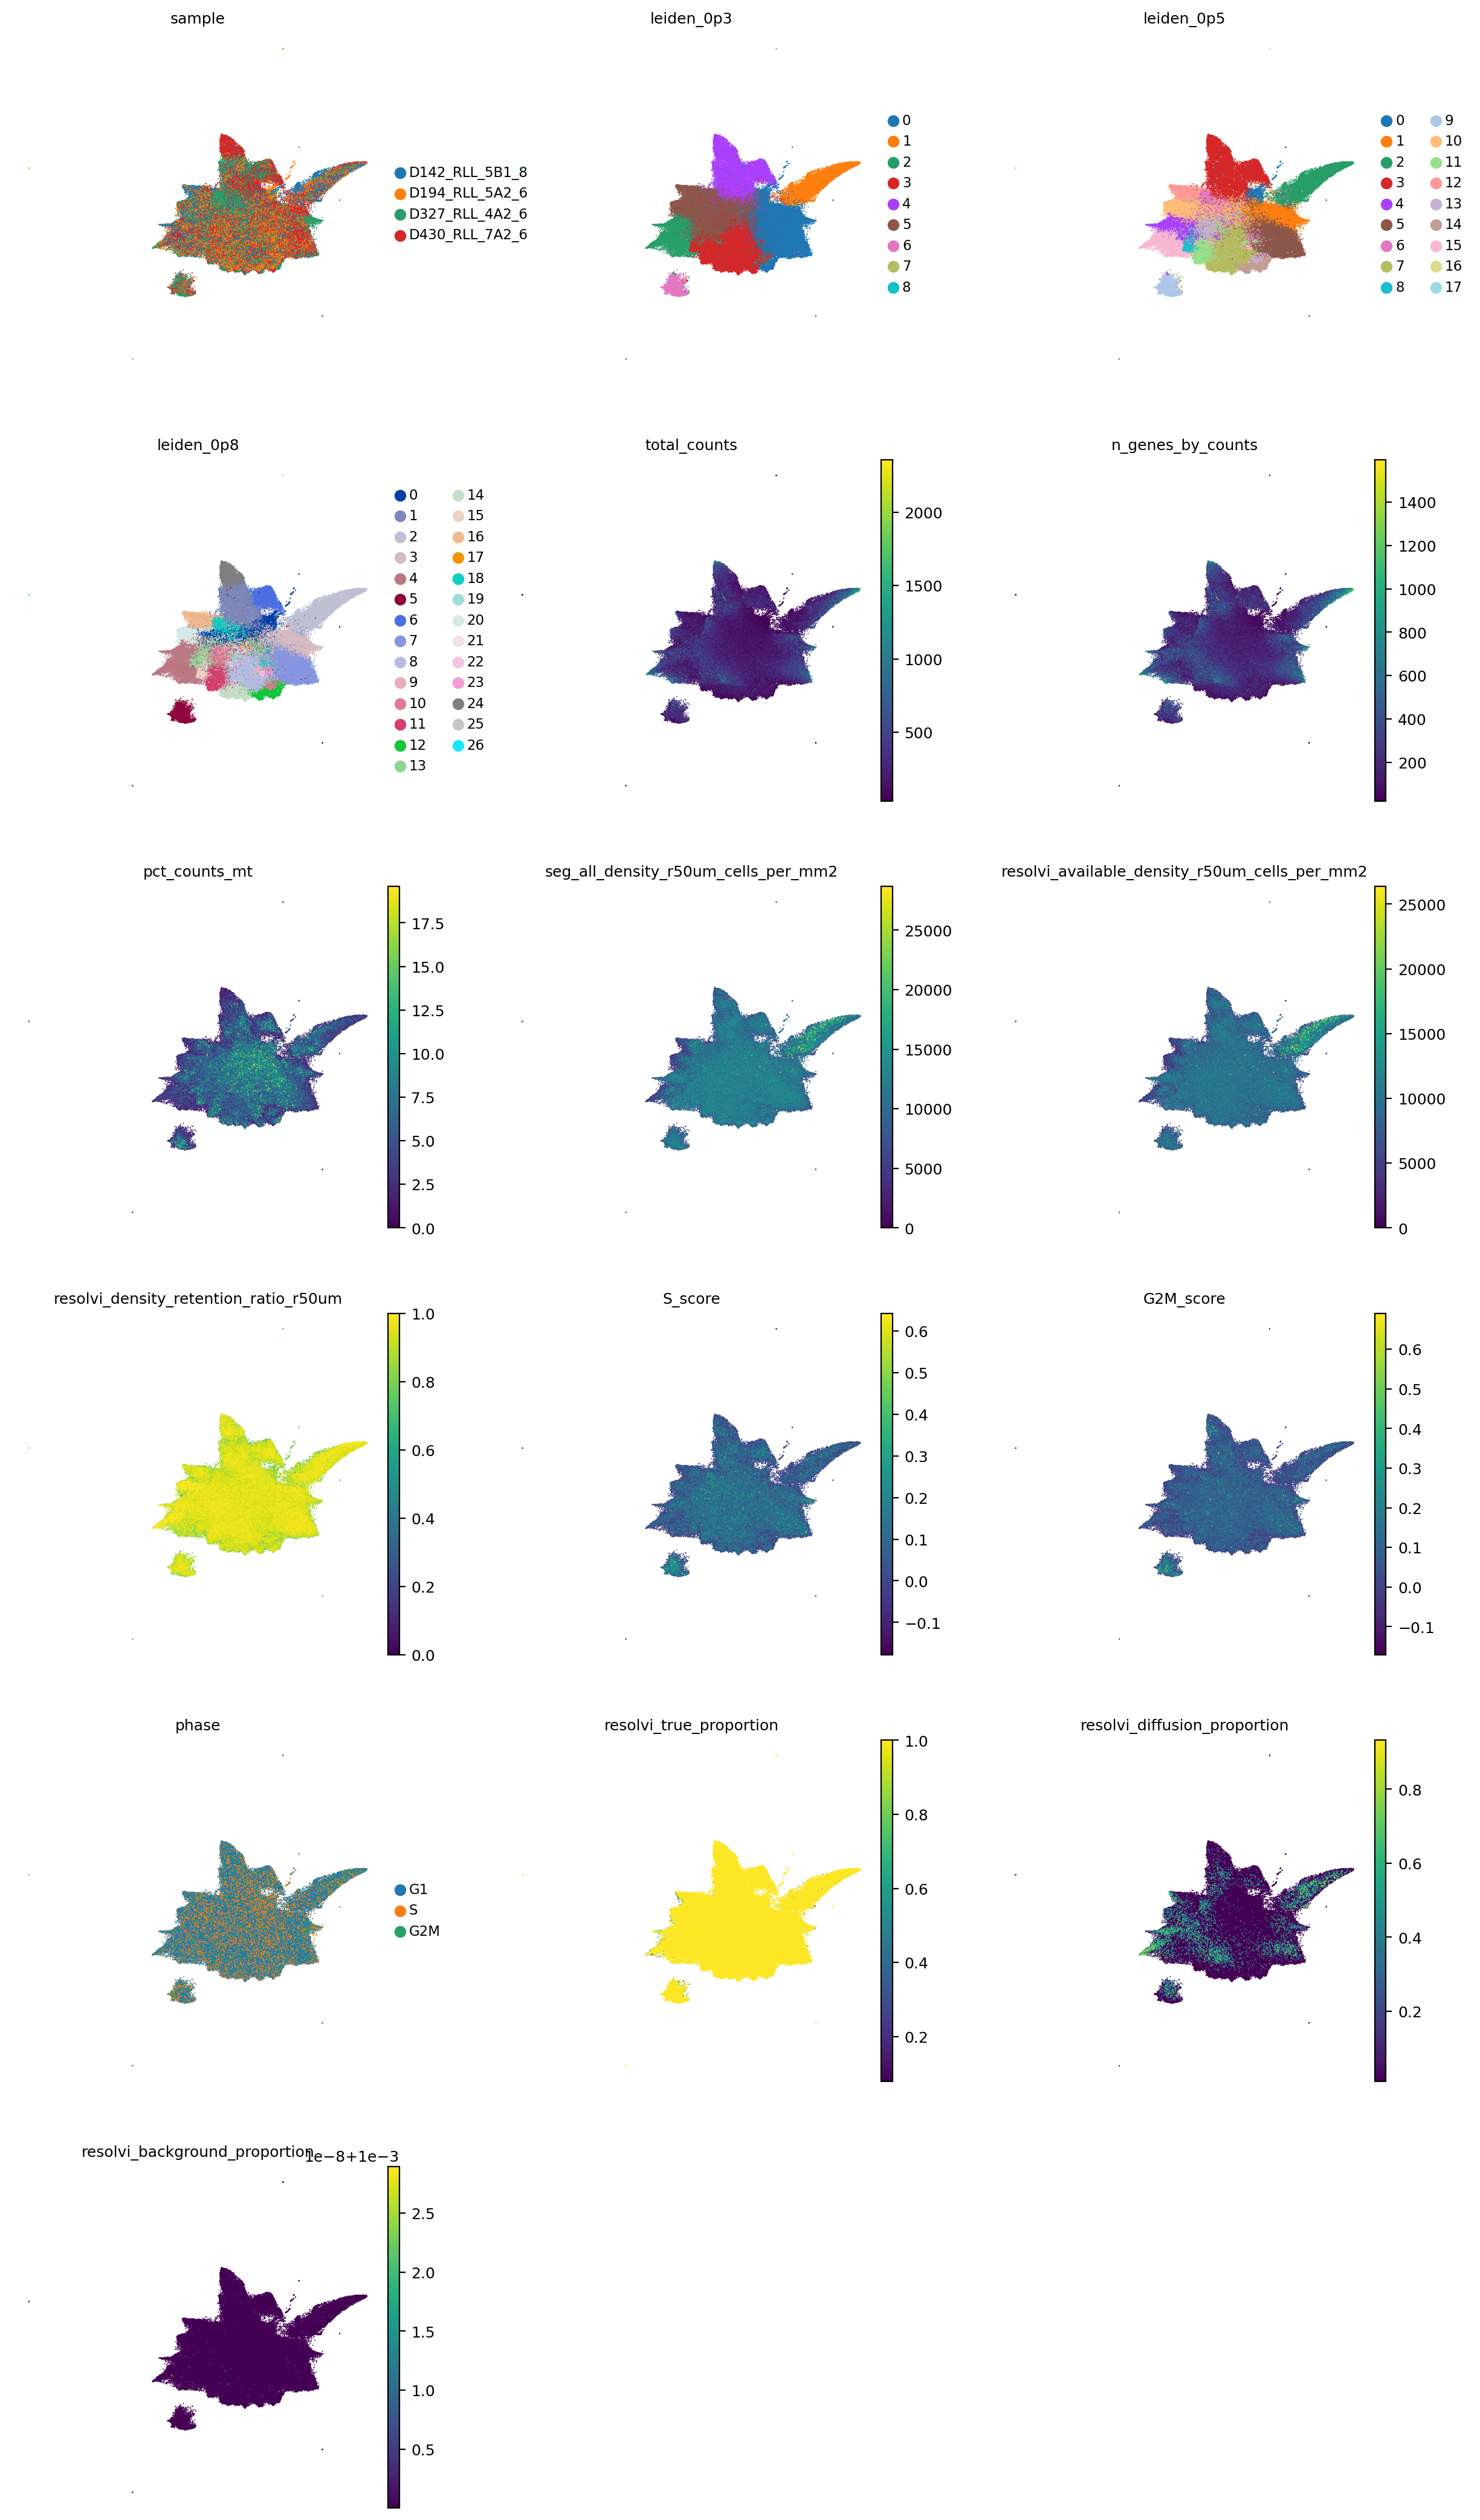

Number of graph connected components: 1


,n_cells,median_total_counts,median_n_genes,median_pct_mt
graph_component,,,,
0,623650,82.0,78.0,1.724138


,n_cells,dominant_sample,dominant_sample_fraction,normalized_sample_entropy
leiden_0p5,,,,
0,8093,D194_RLL_5A2_6,0.319412,0.974090
1,45990,D430_RLL_7A2_6,0.381431,0.935155
2,28462,D142_RLL_5B1_8,0.353419,0.966522
3,84224,D430_RLL_7A2_6,0.445218,0.883279
4,36788,D327_RLL_4A2_6,0.287240,0.990728
5,96764,D430_RLL_7A2_6,0.399312,0.913690
6,33726,D327_RLL_4A2_6,0.662812,0.716298
7,96691,D327_RLL_4A2_6,0.328304,0.965860
8,8077,D327_RLL_4A2_6,0.401139,0.939708


,n_cells,median_total_counts,median_n_genes,median_pct_mt,median_cell_area_um2,median_structural_density_r50um,dominant_sample,dominant_sample_fraction,normalized_sample_entropy
leiden_0p5,,,,,,,,,
17,15,34.0,34.0,0.000000,44.0,10313.240312,D194_RLL_5A2_6,1.000000,0.000000
16,13,35.0,35.0,2.000000,40.0,9549.296586,D194_RLL_5A2_6,1.000000,0.000000
0,8093,38.0,37.0,2.040816,40.0,7639.437268,D194_RLL_5A2_6,0.319412,0.974090
10,60965,60.0,56.0,1.724138,60.0,6748.169587,D327_RLL_4A2_6,0.308357,0.991391
6,33726,72.0,69.0,1.923077,52.0,8021.409132,D327_RLL_4A2_6,0.662812,0.716298
12,10140,74.0,70.0,1.562500,64.0,6366.197724,D142_RLL_5B1_8,0.280769,0.997664
8,8077,76.0,72.0,1.807229,60.0,8021.409132,D327_RLL_4A2_6,0.401139,0.939708
7,96691,77.0,74.0,1.639344,60.0,7894.085177,D327_RLL_4A2_6,0.328304,0.965860
13,34211,78.0,75.0,1.492537,60.0,7894.085177,D194_RLL_5A2_6,0.368390,0.923061


,method,n_cells,n_genes,n_graph_connected_components,largest_graph_component_fraction,full_graph_cross_sample_edge_fraction,full_graph_mean_normalized_sample_lisi,full_graph_median_normalized_sample_lisi,weighted_primary_leiden_sample_purity,weighted_primary_leiden_sample_entropy,n_primary_leiden_clusters,n_clusters_at_least_99pct_one_sample,harmony_relative_l2_change
0,raw_backbone_mt20_genes20_counts30_recurrentHV...,623650,3000,1,1.0,0.50408,0.451551,0.459861,0.37953,0.93142,18,2,0.2389


In [11]:
# ---------------------------------------------------------------------
# Diagnostic plots, graph components, cluster QC, and integration audit
# ---------------------------------------------------------------------
rng = np.random.default_rng(
    RANDOM_SEED
)

if graph.n_obs > PLOT_MAX_CELLS:
    selected_positions = []

    grouping = graph.obs[
        [
            "sample",
            PRIMARY_LEIDEN_KEY,
        ]
    ].astype(str)

    for _, group_index in grouping.groupby(
        [
            "sample",
            PRIMARY_LEIDEN_KEY,
        ]
    ).groups.items():
        positions = np.asarray(
            [
                graph.obs_names.get_loc(
                    value
                )
                for value in group_index
            ],
            dtype=np.int64,
        )

        target = max(
            50,
            round(
                PLOT_MAX_CELLS
                * len(positions)
                / graph.n_obs
            ),
        )
        target = min(
            target,
            len(positions),
        )

        selected_positions.extend(
            rng.choice(
                positions,
                size=target,
                replace=False,
            ).tolist()
        )

    selected_positions = np.unique(
        selected_positions
    )

    if (
        len(selected_positions)
        > PLOT_MAX_CELLS
    ):
        selected_positions = rng.choice(
            selected_positions,
            size=PLOT_MAX_CELLS,
            replace=False,
        )

    plot_data = graph[
        selected_positions
    ].copy()

else:
    plot_data = graph

plot_columns = [
    "sample",
    "leiden_0p3",
    "leiden_0p5",
    "leiden_0p8",
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "seg_all_density_r50um_cells_per_mm2",
    "resolvi_available_density_r50um_cells_per_mm2",
    "resolvi_density_retention_ratio_r50um",
]

for optional in [
    "S_score",
    "G2M_score",
    "phase",
    "resolvi_true_proportion",
    "resolvi_diffusion_proportion",
    "resolvi_background_proportion",
]:
    if optional in plot_data.obs:
        plot_columns.append(
            optional
        )

sc.pl.umap(
    plot_data,
    color=plot_columns,
    ncols=3,
    size=2,
    show=False,
)
plt.savefig(
    FIGURE_ROOT
    / "LungDev_backbone_UMAP_QC_batch_density.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# Graph connected components.
n_components, component_labels = (
    connected_components(
        graph.obsp[
            "connectivities"
        ],
        directed=False,
    )
)

graph.obs[
    "graph_component"
] = pd.Categorical(
    component_labels.astype(str)
)

component_summary = (
    graph.obs.groupby(
        "graph_component",
        observed=True,
    )
    .agg(
        n_cells=(
            "total_counts",
            "size",
        ),
        median_total_counts=(
            "total_counts",
            "median",
        ),
        median_n_genes=(
            "n_genes_by_counts",
            "median",
        ),
        median_pct_mt=(
            "pct_counts_mt",
            "median",
        ),
    )
    .sort_values(
        "n_cells",
        ascending=False,
    )
)

component_summary.to_csv(
    GRAPH_COMPONENTS_CSV
)

print(
    "Number of graph connected components:",
    n_components,
)
display(
    component_summary.head(30)
)

# Cluster/sample composition.
cluster_sample_counts = pd.crosstab(
    graph.obs[
        PRIMARY_LEIDEN_KEY
    ],
    graph.obs["sample"],
)

cluster_sample_fraction = (
    cluster_sample_counts.div(
        cluster_sample_counts.sum(
            axis=1
        ),
        axis=0,
    )
)

cluster_sample_purity = pd.DataFrame(
    {
        "n_cells": (
            cluster_sample_counts.sum(
                axis=1
            )
        ),
        "dominant_sample": (
            cluster_sample_counts.idxmax(
                axis=1
            )
        ),
        "dominant_sample_fraction": (
            cluster_sample_counts.max(
                axis=1
            )
            / cluster_sample_counts.sum(
                axis=1
            )
        ),
    }
)

with np.errstate(
    divide="ignore",
    invalid="ignore",
):
    entropy_terms = (
        -cluster_sample_fraction
        * np.log(
            cluster_sample_fraction.replace(
                0,
                np.nan,
            )
        )
    )

cluster_sample_purity[
    "normalized_sample_entropy"
] = (
    entropy_terms.sum(
        axis=1
    )
    / np.log(
        cluster_sample_counts.shape[
            1
        ]
    )
)

cluster_sample_purity.to_csv(
    CLUSTER_SAMPLE_PURITY_CSV
)

# Cluster QC, useful for deciding whether stricter cell thresholds are needed.
cluster_qc = (
    graph.obs.groupby(
        PRIMARY_LEIDEN_KEY,
        observed=True,
    )
    .agg(
        n_cells=(
            "total_counts",
            "size",
        ),
        median_total_counts=(
            "total_counts",
            "median",
        ),
        median_n_genes=(
            "n_genes_by_counts",
            "median",
        ),
        median_pct_mt=(
            "pct_counts_mt",
            "median",
        ),
        median_cell_area_um2=(
            "cell_area_um2",
            "median",
        ),
        median_structural_density_r50um=(
            "seg_all_density_r50um_cells_per_mm2",
            "median",
        ),
    )
)

cluster_qc = cluster_qc.join(
    cluster_sample_purity[
        [
            "dominant_sample",
            "dominant_sample_fraction",
            "normalized_sample_entropy",
        ]
    ],
    how="left",
)

cluster_qc.to_csv(
    CLUSTER_QC_CSV
)

full_neighbor_metrics = (
    neighborhood_sample_metrics(
        graph.obsp[
            "distances"
        ],
        graph.obs[
            "sample"
        ].astype(str),
    )
)

weighted_cluster_purity = float(
    (
        cluster_sample_purity[
            "dominant_sample_fraction"
        ]
        * cluster_sample_purity[
            "n_cells"
        ]
    ).sum()
    / cluster_sample_purity[
        "n_cells"
    ].sum()
)

weighted_cluster_entropy = float(
    (
        cluster_sample_purity[
            "normalized_sample_entropy"
        ]
        * cluster_sample_purity[
            "n_cells"
        ]
    ).sum()
    / cluster_sample_purity[
        "n_cells"
    ].sum()
)

integration_audit = {
    "method": (
        "raw_backbone_mt20_genes20_counts30_"
        "recurrentHVG3000_PCA80_Harmony40_"
        "CAGRA50"
    ),
    "n_cells": int(
        graph.n_obs
    ),
    "n_genes": int(
        graph.n_vars
    ),
    "n_graph_connected_components": int(
        n_components
    ),
    "largest_graph_component_fraction": float(
        component_summary[
            "n_cells"
        ].iloc[0]
        / graph.n_obs
    ),
    "full_graph_cross_sample_edge_fraction": (
        full_neighbor_metrics[
            "cross_sample_edge_fraction"
        ]
    ),
    "full_graph_mean_normalized_sample_lisi": (
        full_neighbor_metrics[
            "mean_normalized_sample_lisi"
        ]
    ),
    "full_graph_median_normalized_sample_lisi": (
        full_neighbor_metrics[
            "median_normalized_sample_lisi"
        ]
    ),
    "weighted_primary_leiden_sample_purity": (
        weighted_cluster_purity
    ),
    "weighted_primary_leiden_sample_entropy": (
        weighted_cluster_entropy
    ),
    "n_primary_leiden_clusters": int(
        len(
            cluster_sample_purity
        )
    ),
    "n_clusters_at_least_99pct_one_sample": int(
        (
            cluster_sample_purity[
                "dominant_sample_fraction"
            ]
            >= 0.99
        ).sum()
    ),
    "harmony_relative_l2_change": (
        relative_l2_change
    ),
}

pd.DataFrame(
    [integration_audit]
).to_csv(
    INTEGRATION_AUDIT_CSV,
    index=False,
)

display(
    cluster_sample_purity
)
display(
    cluster_qc.sort_values(
        [
            "median_n_genes",
            "median_total_counts",
        ]
    ).head(30)
)
display(
    pd.DataFrame(
        [integration_audit]
    )
)


In [12]:
# ---------------------------------------------------------------------
# Compare with prior integration branches when their audit files exist
# ---------------------------------------------------------------------
comparison_rows = [
    integration_audit
]

for method, candidate_paths in (
    PRIOR_BRANCH_AUDIT_CANDIDATES.items()
):
    audit_path = next(
        (
            path
            for path in candidate_paths
            if path.exists()
        ),
        None,
    )

    if audit_path is None:
        continue

    prior = pd.read_csv(
        audit_path
    )

    if len(prior) == 0:
        continue

    row = prior.iloc[
        0
    ].to_dict()
    row["method"] = method
    comparison_rows.append(
        row
    )

comparison = pd.DataFrame(
    comparison_rows
)

comparison.to_csv(
    BRANCH_COMPARISON_CSV,
    index=False,
)

display(
    comparison
)


,method,n_cells,n_genes,n_graph_connected_components,largest_graph_component_fraction,full_graph_cross_sample_edge_fraction,full_graph_mean_normalized_sample_lisi,full_graph_median_normalized_sample_lisi,weighted_primary_leiden_sample_purity,weighted_primary_leiden_sample_entropy,n_primary_leiden_clusters,n_clusters_at_least_99pct_one_sample,harmony_relative_l2_change,weighted_leiden_0p8_sample_purity,weighted_leiden_0p8_normalized_sample_entropy,n_clusters
0,raw_backbone_mt20_genes20_counts30_recurrentHV...,623650.0,3000.0,1.0,1.0,0.504080,0.451551,0.459861,0.37953,0.93142,18.0,2.0,0.238900,NaN,NaN,NaN
1,per_sample_ResolVI_corrected,NaN,NaN,NaN,NaN,0.005557,0.003836,NaN,NaN,NaN,NaN,26.0,0.569258,0.978137,0.02988,31.0
2,raw_all_analysis_core_old06C,NaN,NaN,NaN,NaN,0.537177,0.432897,0.434703,NaN,NaN,NaN,46.0,0.247793,0.370502,0.94265,134.0


## 5. Save the backbone graph and annotation template

The graph H5AD contains embeddings, graph, clusters, QC, density, and ResolVI
diagnostic columns. Its `.X` remains a zero sparse placeholder; normalized
expression is stored in the sparse stage Zarr.

The full-cell QC Parquet preserves all excluded cells and their reasons.


In [13]:
# ---------------------------------------------------------------------
# Final H5AD-safe save
# ---------------------------------------------------------------------
annotation_template = pd.DataFrame(
    {
        PRIMARY_LEIDEN_KEY: (
            graph.obs[
                PRIMARY_LEIDEN_KEY
            ].cat.categories.astype(
                str
            )
        ),
        "reviewed_broad_lineage": "",
        "reviewed_cell_type": "",
        "annotation_confidence": "",
        "notes": "",
    }
)

annotation_template.to_csv(
    ANNOTATION_TEMPLATE_CSV,
    index=False,
)

graph.obs[
    "cell_type_manual"
] = pd.Categorical(
    ["Unassigned"] * graph.n_obs
)

graph.uns[
    "backbone_rawcount_integration_provenance"
] = {
    "samples": SAMPLE_IDS,
    "source_raw_checkpoint": str(
        raw_checkpoint_path
    ),
    "cell_filter": {
        "pct_counts_mt_lt": float(
            MAX_PCT_COUNTS_MT
        ),
        "n_genes_by_counts_gte": int(
            MIN_GENES_BY_COUNTS
        ),
        "total_counts_gte": int(
            MIN_TOTAL_COUNTS
        ),
    },
    "modeling_gene_filter": {
        "min_cells_per_gene": int(
            MIN_CELLS_PER_MODEL_GENE
        ),
        "min_hvg_batches": int(
            MIN_HVG_BATCHES
        ),
        "candidate_pool": int(
            HVG_CANDIDATE_POOL
        ),
        "selected_identity_hvg": int(
            graph.n_vars
        ),
        "excluded_classes": [
            "mitochondrial",
            "ribosomal",
            "hemoglobin",
            "standard_S_and_G2M_cell_cycle",
        ],
    },
    "normalization": {
        "target_sum": float(
            TARGET_SUM
        ),
        "size_factor_denominator": (
            "all-gene raw Proseg count row sum"
        ),
        "transform": (
            "natural log1p"
        ),
    },
    "pca": {
        "n_components_computed": int(
            N_PCS
        ),
        "n_harmony_components_for_graph": int(
            N_HARMONY_PCS_FOR_GRAPH
        ),
        "solver": (
            "covariance_eigh"
        ),
        "zero_center": bool(
            SCALE_ZERO_CENTER
        ),
        "scale_max_value": float(
            SCALE_MAX_VALUE
        ),
    },
    "harmony_audit": (
        embedding_audit
    ),
    "harmony_subset_neighbor_mixing": (
        dataframe_to_h5ad_mapping(
            harmony_subset_mixing
        )
    ),
    "graph": {
        "use_rep": (
            "X_pca_harmony_graph"
        ),
        "n_neighbors": int(
            N_NEIGHBORS
        ),
        "algorithm": (
            NEIGHBOR_ALGORITHM
        ),
    },
    "integration_audit": (
        integration_audit
    ),
    "full_cell_qc_metadata": str(
        ALL_CELL_QC_PARQUET
    ),
    "normalized_expression_stage": str(
        LOGNORM_STAGE_ZARR
    ),
}

atomic_write_h5ad(
    graph,
    GRAPH_CHECKPOINT_H5AD,
)

graph.obs.to_parquet(
    TABLE_ROOT
    / "LungDev_backbone_integrated_cell_metadata.parquet"
)
graph.var.to_csv(
    TABLE_ROOT
    / "LungDev_backbone_integrated_gene_metadata.csv"
)

GRAPH_MANIFEST_JSON.write_text(
    json.dumps(
        {
            "shape": list(
                map(
                    int,
                    graph.shape,
                )
            ),
            "pca_shape": list(
                map(
                    int,
                    graph.obsm[
                        "X_pca"
                    ].shape,
                )
            ),
            "harmony_shape": list(
                map(
                    int,
                    graph.obsm[
                        "X_pca_harmony"
                    ].shape,
                )
            ),
            "graph_input_shape": list(
                map(
                    int,
                    graph.obsm[
                        "X_pca_harmony_graph"
                    ].shape,
                )
            ),
            "umap_shape": list(
                map(
                    int,
                    graph.obsm[
                        "X_umap"
                    ].shape,
                )
            ),
            "leiden_keys": [
                column
                for column in graph.obs
                if column.startswith(
                    "leiden_"
                )
            ],
            "graph_checkpoint": str(
                GRAPH_CHECKPOINT_H5AD
            ),
            "normalized_stage": str(
                LOGNORM_STAGE_ZARR
            ),
            "pca_checkpoint": str(
                PCA_CHECKPOINT_H5AD
            ),
            "all_cell_qc_metadata": str(
                ALL_CELL_QC_PARQUET
            ),
        },
        indent=2,
    )
)

display(
    annotation_template
)
print(
    "Final backbone graph:",
    GRAPH_CHECKPOINT_H5AD,
)
print(
    "Full-cell QC metadata:",
    ALL_CELL_QC_PARQUET,
)
print(
    "Normalized sparse expression stage:",
    LOGNORM_STAGE_ZARR,
)


,leiden_0p5,reviewed_broad_lineage,reviewed_cell_type,annotation_confidence,notes
0,0,,,,
1,1,,,,
2,2,,,,
3,3,,,,
4,4,,,,
5,5,,,,
6,6,,,,
7,7,,,,
8,8,,,,
9,9,,,,


Final backbone graph: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06D_rawcounts_backboneQC_recurrentHVG/04_harmony_graph/LungDev_backbone_Harmony40_CAGRA50_UMAP_Leiden.h5ad
Full-cell QC metadata: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06D_rawcounts_backboneQC_recurrentHVG/01_backbone_qc/LungDev_all_cells_backbone_QC_flags.parquet
Normalized sparse expression stage: /host_root/nethome/reny28/Projects/ShortProject/LungDev_VisiumHD_example/tmp/lungdev_stardist_proseg_resolvi_v1/06_rapids_multigpu/06D_rawcounts_backboneQC_recurrentHVG/02_lognorm_hvg_stage/LungDev_backbone_allgeneSF_log1p_recurrentHVG.zarr


## Interpretation and next decision

### Favor the raw backbone atlas when

- the largest connected component contains nearly all retained cells;
- the number of broad Leiden clusters is substantially reduced;
- cluster medians are no longer concentrated near the QC floors;
- samples mix within shared lung lineages;
- major epithelial, endothelial, immune, and stromal programs remain distinct.

### Tighten the backbone only when

small graph components or Leiden clusters remain strongly associated with:

```text
median genes close to 20
median counts close to 30
high mitochondrial percentage
extreme cell area
```

A reasonable next sensitivity filter would be:

```python
n_genes_by_counts >= 30
total_counts >= 50
pct_counts_mt < 20
```

but that stricter condition should not be applied before reviewing the cluster
QC table generated here.

### Move to a joint model when

the correctly normalized, recurrent-HVG backbone remains strongly
sample-separated or biologically incoherent despite reasonable cluster QC.
The next model should be one jointly trained scVI or ResolVI model with
`batch_key="sample"`.
